playground combining all newly created functions for new image formats. going to try using new rgb function here. 

playground is to define the new functions and build a caller/new function based on user input to determine which plot to generate

currently excludes plotting from other_rgb_function_playground bc each one was so different. unsure how to simplify

In [18]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import new_utils

In [2]:
HE_SHEET = "he test.xlsx"

df = pd.read_excel(HE_SHEET)
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [3]:
y_title = 'Intensity'
x_title = 'Wavelength (nm)'
fig_size = (15,6)
prominence = 0.12
min_bright = 0.1
min_alpha = 0.1
min_alpha_scatter = 0.2
base_marker_size = 5
max_marker_size_factor = 95
gamma_factor = 0.8
bar_width = 1
smoothing_window = 5    # Increase this value to control the degree of smoothing
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be
x_min = 400
x_max = 750
mode = 'dark'
reverse_x = True
show_grid = True
plot_type = None

x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

In [4]:
df_filtered['Smoothed_int'] = df_filtered['Grey Val'].rolling(window=smoothing_window, center=True).mean().fillna(df_filtered['Grey Val'])

if plot_type == 'Smoothed':
    min_int = df_filtered['Smoothed_int'].min
    max_int = df_filtered['Smoothed_int'].max
else:
    min_int = df_filtered['Grey Val'].min()
    max_int = df_filtered['Grey Val'].max()

int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    if plot_type == 'Smoothed':
        df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
    else:
        df_filtered['Normalized_int'] = (df_filtered['Grey Val'] - min_int) / int_range

In [19]:
rgb = new_utils.rgb

In [26]:
def axis_labels(
    fig_size = (15, 6),
    mode = None,
    show_grid = True,
    x_min = 400,
    x_max = 750,
    x_title = "Wavelength (nm)",
    y_title = "Intensity",
    text = None,
    reverse_x = None,
):
    
    plt.figure(figsize=fig_size)
    ax = plt.gca()

    mode = input(print("Choose Mode: Dark or Light")).lower()
    if mode == 'dark':
        fig_bg = 'black'
        text = 'white'
        plt.gcf().set_facecolor('black')
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = 'white'
        text = 'black'
        if show_grid is True:
            plt.grid(show_grid)
    
    reverse_x = input(print("Reverse x-axis? Yes or No")).lower()
    if reverse_x == 'yes':
        reverse_x is True
        plt.xlim(x_max, x_min)
    else:
        reverse_x is False
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)

In [7]:
def dynamic_prominence(prominence, int_range):
    dyn_prom = prominence * int_range
    return dyn_prom

In [8]:
def final_scale(min, factor):
    final = min + (1 - min) * factor
    return final

# for final_alpha AND final_intensity_scale

In [9]:
def colored_rgb(base_rgb, final_intensity_scale):
    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)
    return colored_rgb

In [10]:
def line_plot_iteration():  
    axis_labels()
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i]['nm']
        wavelength_end = df_filtered.iloc[i+1]['nm']

        int_factor = df_filtered.iloc[i]['Normalized_int']
        base_rgb = rgb(wavelength_start)
        final_intensity_scale = final_scale(min_bright, int_factor)
        
        color_rgb = colored_rgb(base_rgb, final_intensity_scale)

        plt.plot([wavelength_start, wavelength_end],
                [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
                color=color_rgb,
                linewidth=2)
    

In [11]:
def filled_plot():
    axis_labels()
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i]['nm']
        wavelength_end = df_filtered.iloc[i+1]['nm']

        base_rgb = rgb(wavelength_start)

        alpha_factor = df_filtered.iloc[i]['Normalized_int']
        alpha = final_scale(min_alpha, alpha_factor)

        if plot_type == 'Smoothed':
            plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Smoothed_int'], df_filtered.iloc[i+1]['Smoothed_int']], # Top of the fill
                     color=base_rgb,
                     alpha=alpha,
                     linewidth=0) # No line for the fill edges
        else:
            plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0], # Base of the fill is y=0
                        [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']], # Top of the fill
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0) # No line for the fill edges

              # Plot the line on top for clarity, using the base color for the line itself
            plt.plot([wavelength_start, wavelength_end],
                    [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
                    color=base_rgb,
                    linewidth=2) # Thicker line for better visibility on top of fill

In [12]:
def peak_labels():
    peaks, _ = find_peaks(df_filtered['Grey Val'], prominence=dynamic_prominence(prominence, int_range))
    for peak_index in peaks:
        row = df_filtered.iloc[peak_index]
        plt.annotate(f"{row['nm']:.2f} nm", # Formatted nm to two decimal places
                    (row['nm'], row['Grey Val']),
                    textcoords="offset points", # Offset the text
                    xytext=(0,10), # Distance from point to label
                    ha='center', # Horizontal alignment
                    bbox=dict(boxstyle="round,pad=0.3", fc="red", ec="b", lw=0.5, alpha=0.7),
                    arrowprops=dict(facecolor='black', shrink=0.05))

In [13]:
def gaussian_iteration():
    axis_labels()
    df_plot_data = df_filtered[(df_filtered['nm'] >= 400) & (df_filtered['nm'] <= 750)].copy()
    df_plot_data = df_plot_data.sort_values(by='nm').reset_index(drop=True)

    # Detect peaks
    dyn_prominence = dynamic_prominence(prominence, int_range)
    peaks_indices, properties = find_peaks(df_plot_data['Grey Val'], prominence=dyn_prominence)

    # Create a new, denser wavelength array for plotting the synthetic spectrum
    x_synthetic = np.linspace(400, 750, 1000) # 1000 points for a smooth synthetic curve
    y_synthetic = np.zeros_like(x_synthetic)

    for i, peak_idx in enumerate(peaks_indices):
        peak_nm = df_plot_data.iloc[peak_idx]['nm']
        peak_amplitude = df_plot_data.iloc[peak_idx]['Grey Val']
        normalized_amplitude = df_plot_data.iloc[peak_idx]['Normalized_int']

        # Scale sigma based on normalized intensity (higher intensity = broader peak)
        sigma = base_sigma_nm + (max_sigma_multiplier - 1) * base_sigma_nm * normalized_amplitude

        # Create a Gaussian curve for this peak
        gaussian_curve = peak_amplitude * np.exp(-((x_synthetic - peak_nm)**2) / (2 * sigma**2))
        y_synthetic += gaussian_curve # Add to the total synthetic spectrum

    # Normalize the synthetic spectrum intensities for coloring (if desired, not strictly necessary for area plot)
    min_y_synthetic = y_synthetic.min()
    max_y_synthetic = y_synthetic.max()
    if (max_y_synthetic - min_y_synthetic) == 0:
        normalized_y_synthetic = np.ones_like(y_synthetic)
    else:
        normalized_y_synthetic = (y_synthetic - min_y_synthetic) / (max_y_synthetic - min_y_synthetic)

        # Iterate through each segment of the synthetic spectrum to apply color and alpha
    for i in range(len(x_synthetic) - 1):
        wavelength_start = x_synthetic[i]
        wavelength_end = x_synthetic[i+1]

        base_rgb = rgb(wavelength_start, gamma=gamma_factor)

        alpha = final_scale(min_alpha, normalized_y_synthetic[i])

        plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0],
                        [y_synthetic[i], y_synthetic[i+1]],
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0)
        

In [14]:
def scatter_iteration():
    axis_labels()
    alpha_factor = df_filtered['Normalized_int']
    sizes = base_marker_size + (max_marker_size_factor * alpha_factor)
    alphas = final_scale(min_alpha_scatter, alpha_factor)

    # Create RGBA tuples for each point
    rgba_colors = []
    for i in range(len(df_filtered)):
        wavelength = df_filtered.iloc[i]['nm']
        r, g, b = rgb(wavelength)
        a = alphas.iloc[i]
        rgba_colors.append((r, g, b, a))

    plt.scatter(
        x=df_filtered['nm'],
        y=df_filtered['Grey Val'],
        c=rgba_colors,
        s=sizes,
        edgecolors='none', # No edge colors for the markers
        label='Emission Data'
    )

In [15]:
def bar_iteration():
    axis_labels()
    bar_colors = []
    for index, row in df_filtered.iterrows():
        wavelength = row['nm']
        normalized_intensity = row['Normalized_int']

        base_rgb = rgb(wavelength)
        final_intensity_scale = final_scale(min_bright, normalized_intensity)
        color_rgb = colored_rgb(base_rgb, final_intensity_scale)
        bar_colors.append(color_rgb)

    plt.bar(
        x=df_filtered['nm'],
        height=df_filtered['Grey Val'],
        width=bar_width,
        color=bar_colors,
        edgecolor='none' # No edge color for bars
    )

GRAPH_TYPE = input(print("Choose Graph Type: Line, Bar, Scatter, Gaussian")).lower()
FILL_TYPE = input(print("Filled Graph? Choose: Yes or No")).lower()
PLOT_TYPE = input(print("Smoothed Fill? Choose: Yes or No")).lower()

# 1. ask GRAPH_TYPE
# 2. if GRAPH_TYPE = line, ask FILL_TYPE and PLOT_TYPE
# 3. if GRAPH_TYPE is NOT line, move straight to iteration

if GRAPH_TYPE == 'bar':
    axis_labels()
    bar_iteration()
    plt.title("Bar Chart", color = "white")
elif GRAPH_TYPE == 'scatter':
    axis_labels()
    scatter_iteration()
    plt.title("Scatter Plot", color="white")
elif GRAPH_TYPE == 'Gaussian':
    axis_labels()
    gaussian_iteration()
    plt.title("Gaussian Plot", color = "white")
elif GRAPH_TYPE == 'line':
    if FILL_TYPE == 'yes':
        if PLOT_TYPE == 'yes':
            plot_type == 'Smoothed'
            filled_plot()
            plt.title("Smoothed Plot", color = "white")
        else:
            plot_type is None
            filled_plot()
            plt.title("Filled Plot", color = "white")
    else:
        line_plot_iteration()
        plt.title("Line Plot", color = "white")
plt.show()



In [29]:
def plot_graph():
    GRAPH_TYPE = input(print("Choose Graph Type: Line, Bar, Scatter, Gaussian")).lower()

    if GRAPH_TYPE == 'bar':
        bar_iteration()
        plt.title("Bar Chart", color = "white")
    elif GRAPH_TYPE == 'scatter':
        scatter_iteration()
        plt.title("Scatter Plot", color="white")
    elif GRAPH_TYPE == 'gaussian':
        gaussian_iteration()
        plt.title("Gaussian Plot", color = "white")
    elif GRAPH_TYPE == 'line':
        FILL_TYPE = input(print("Filled Graph? Choose: Yes or No")).lower()
        if FILL_TYPE == 'yes':
            PLOT_TYPE = input(print("Smoothed Fill? Choose: Yes or No")).lower()
            if PLOT_TYPE == 'yes':
                plot_type == 'Smoothed'
                filled_plot()
                plt.title("Smoothed Plot", color = "white")
            else:
                plot_type is None
                filled_plot()
                plt.title("Filled Plot", color = "white")
        else:
            line_plot_iteration()
            plt.title("Line Plot", color = "white")

Choose Graph Type: Line, Bar, Scatter, Gaussian
Choose Mode: Dark or Light
Reverse x-axis? Yes or No


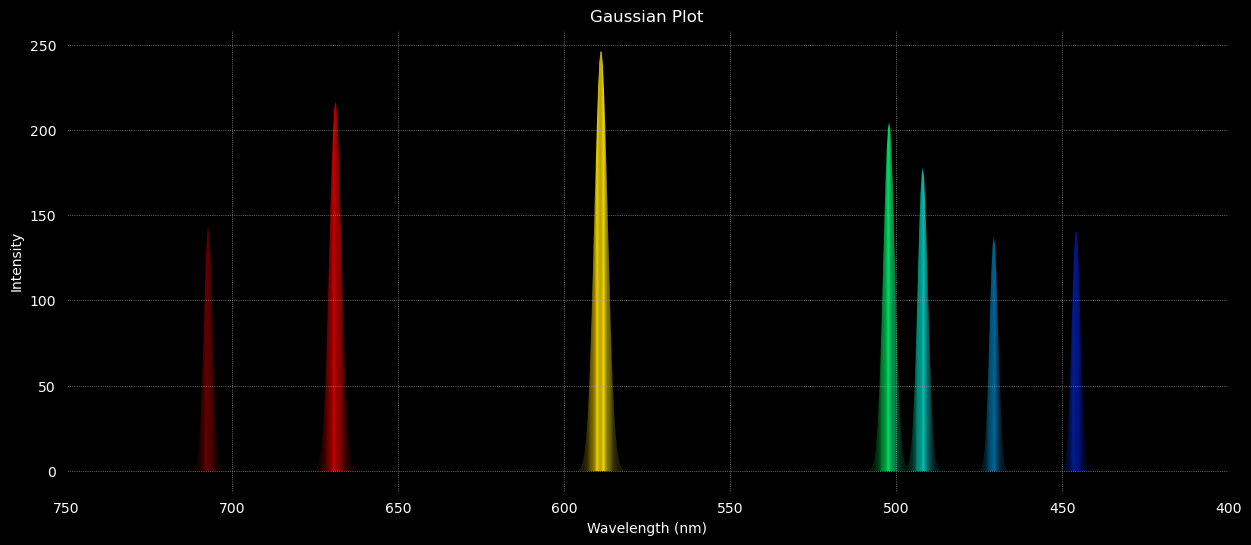

In [31]:
plot_graph()